In [4]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from kneed import KneeLocator

### 1. Environment Setup and Data Cleaning

In [5]:
BASE_DIR = os.getcwd()
RAW_DATA_DIR = os.path.join(BASE_DIR, "data")
CLEAN_DATA_DIR = os.path.join(BASE_DIR, "data", "cleaned")
os.makedirs(CLEAN_DATA_DIR, exist_ok=True)

DATA_PATH = os.path.join(RAW_DATA_DIR, "Crime_Data_from_2020_to_Present.csv")
CLEAN_PATH = os.path.join(CLEAN_DATA_DIR, "Crime_Data_from_2020_to_Present_Cleaned.csv")

df = pd.read_csv(DATA_PATH)

In [6]:
df["LAT"] = pd.to_numeric(df["LAT"], errors="coerce")
df["LON"] = pd.to_numeric(df["LON"], errors="coerce")
df["date_occ"] = pd.to_datetime(df["DATE OCC"], errors="coerce")
df["TIME OCC"] = pd.to_numeric(df["TIME OCC"], errors="coerce")

C:\Users\aryam\AppData\Local\Temp\ipykernel_6648\825594810.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["date_occ"] = pd.to_datetime(df["DATE OCC"], errors="coerce")


In [7]:
df["occ_hour_raw"] = (df["TIME OCC"] // 100)
df["occ_minute_raw"] = (df["TIME OCC"] % 100)
df["occ_hour"] = df["occ_hour_raw"].where(df["occ_hour_raw"].between(0, 23), np.nan)
df["occ_minute"] = df["occ_minute_raw"].where(df["occ_minute_raw"].between(0, 59), np.nan)
df["occ_hour_filled"] = df["occ_hour"].fillna(0).astype(int)
df["occ_datetime"] = df["date_occ"] + pd.to_timedelta(df["occ_hour_filled"], unit="h")

In [8]:
df = df.dropna(subset=["date_occ", "LAT", "LON"])
df = df[(df["LAT"] != 0) & (df["LON"] != 0)]
df = df[df["LAT"].between(-90, 90) & df["LON"].between(-180, 180)]

### 2. Feature Engineering

In [9]:
df["year"] = df["occ_datetime"].dt.year
df["month"] = df["occ_datetime"].dt.month
df["day_of_week"] = df["occ_datetime"].dt.day_name()
df["weekday_num"] = df["occ_datetime"].dt.weekday
df["is_weekend"] = df["weekday_num"].isin([5, 6]).astype(int)

In [10]:
def time_bucket(hour):
    if pd.isna(hour): return "Unknown"
    hour = int(hour)
    if 0 <= hour <= 5: return "Night"
    elif 6 <= hour <= 11: return "Morning"
    elif 12 <= hour <= 17: return "Afternoon"
    elif 18 <= hour <= 23: return "Evening"
    return "Unknown"

df["time_bucket"] = df["occ_hour_filled"].apply(time_bucket)

if "Part 1-2" in df.columns:
    df["crime_category"] = df["Part 1-2"].map({1: "Part1", 2: "Part2"}).fillna("Unknown")
    df["crime_category_simple"] = df["Part 1-2"].map({
        1: "Violent/Serious (Part 1)",
        2: "Property/Other (Part 2)"
    }).fillna("Unknown")

### 3. Exploratory Data Analysis (EDA)

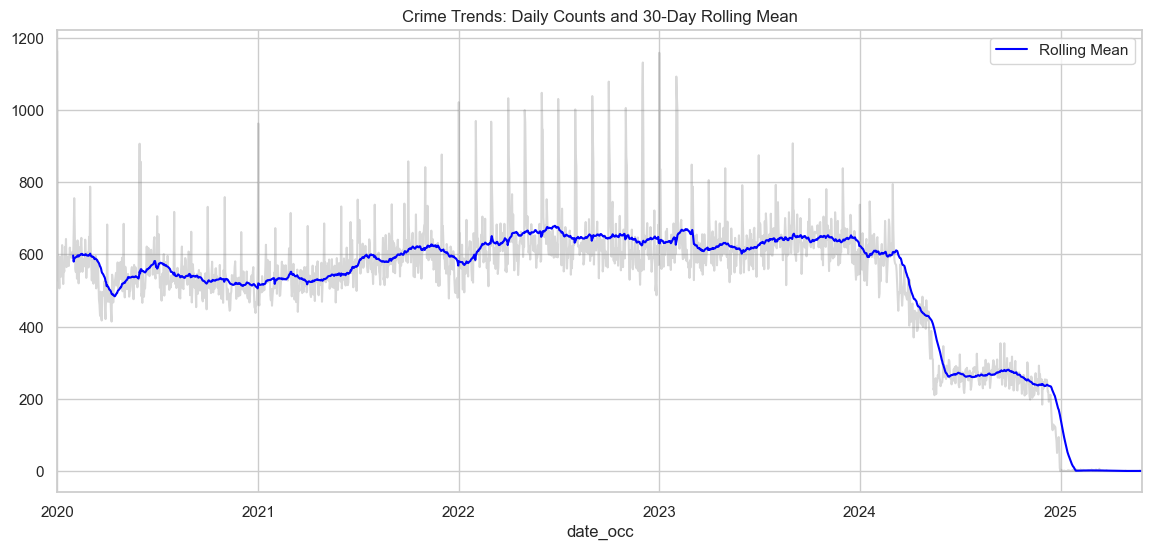

In [11]:
sns.set_theme(style="whitegrid")
daily_counts = df.set_index('date_occ').resample('D').size()

plt.figure(figsize=(14, 6))
daily_counts.plot(alpha=0.3, color='gray')
daily_counts.rolling(window=30).mean().plot(color='blue', label='Rolling Mean')
plt.title('Crime Trends: Daily Counts and 30-Day Rolling Mean')
plt.legend()
plt.show()

### 4. Elbow Method & Spatial Clustering

The mathematically optimal number of clusters (k) is: 3


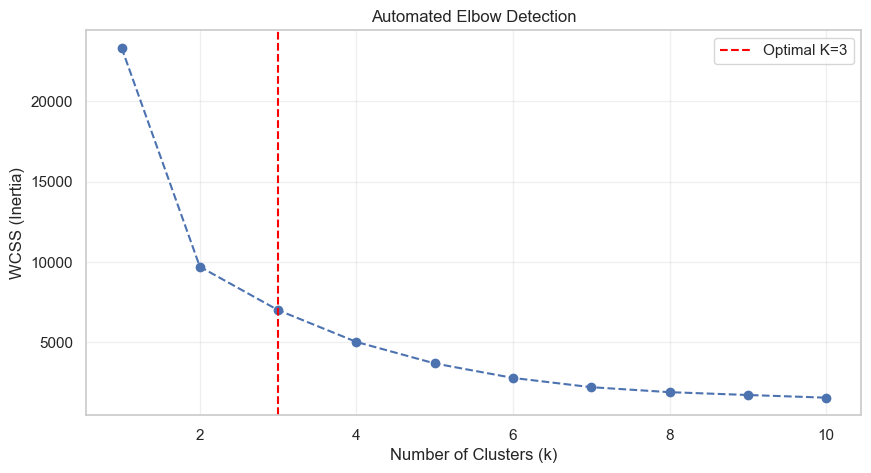

In [12]:
coords = df[["LAT", "LON"]].values

wcss = []
k_range = range(1, 11)
for k in k_range:
    kmeans = KMeans(n_clusters=k, init="k-means++", n_init=10, random_state=42)
    kmeans.fit(coords)
    wcss.append(kmeans.inertia_)

# Automatically find the elbow point
kl = KneeLocator(k_range, wcss, curve="convex", direction="decreasing")
optimal_k = kl.elbow

print(f"The mathematically optimal number of clusters (k) is: {optimal_k}")

# Applying K-Means with the automated optimal K
kmeans_final = KMeans(n_clusters=optimal_k, init="k-means++", n_init=10, random_state=42)
df["spatial_cluster"] = kmeans_final.fit_predict(coords)

# Visualize the automated result
plt.figure(figsize=(10, 5))
plt.plot(k_range, wcss, marker="o", linestyle="--")
plt.axvline(x=optimal_k, color='red', linestyle='--', label=f'Optimal K={optimal_k}')
plt.title("Automated Elbow Detection")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("WCSS (Inertia)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

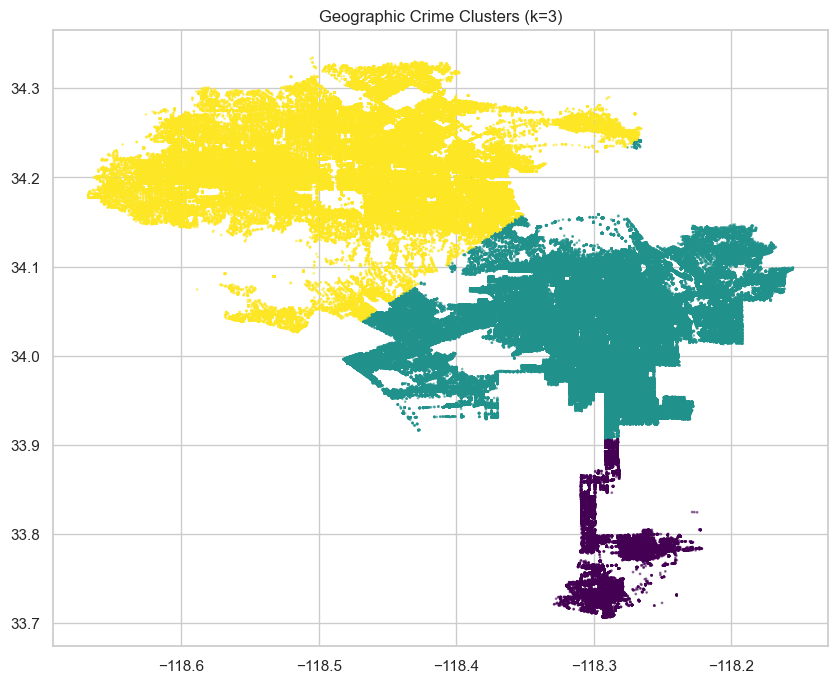

In [13]:
# Applying K-Means (Assuming k=3 based on adjust per elbow plot)

optimal_k = 3
kmeans_final = KMeans(n_clusters=optimal_k, init="k-means++", n_init=10, random_state=42)
df["spatial_cluster"] = kmeans_final.fit_predict(coords)

plt.figure(figsize=(10, 8))
plt.scatter(df["LON"], df["LAT"], c=df["spatial_cluster"], cmap="viridis", s=1, alpha=0.5)
plt.title(f"Geographic Crime Clusters (k={optimal_k})")
plt.show()

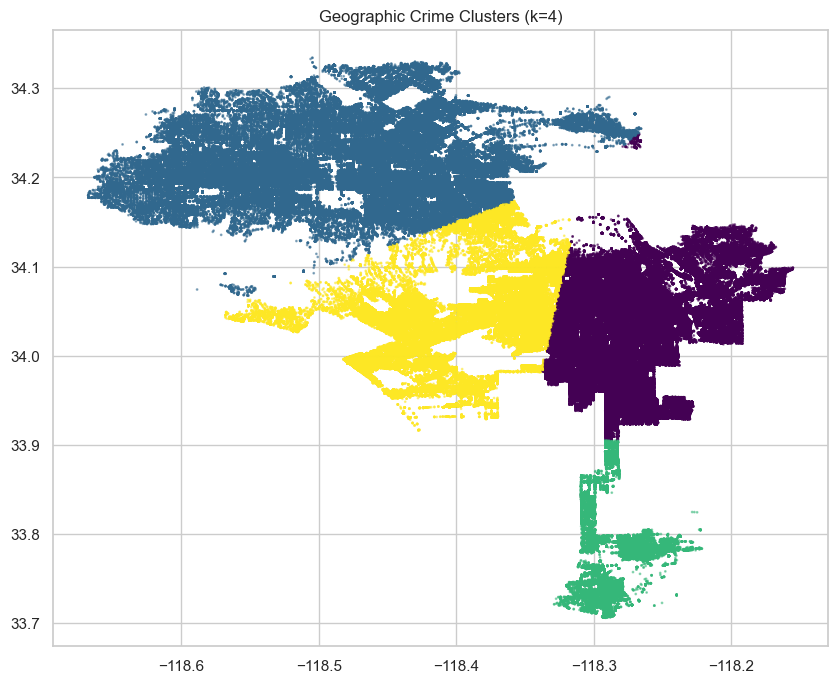

In [20]:
# Applying K-Means (Assuming k=3 based on adjust per elbow plot)

optimal_k = 4
kmeans_final = KMeans(n_clusters=optimal_k, init="k-means++", n_init=10, random_state=42)
df["spatial_cluster"] = kmeans_final.fit_predict(coords)

plt.figure(figsize=(10, 8))
plt.scatter(df["LON"], df["LAT"], c=df["spatial_cluster"], cmap="viridis", s=1, alpha=0.5)
plt.title(f"Geographic Crime Clusters (k={optimal_k})")
plt.show()

### 5. Inferential Statistics (RQ1)

In [14]:
df_rq1 = df[df["crime_category"].isin(["Part1", "Part2"])].copy()
ct_time = pd.crosstab(df_rq1["crime_category"], df_rq1["time_bucket"])
chi2, p, dof, expected = stats.chi2_contingency(ct_time)
n = ct_time.values.sum()
cramers_v = np.sqrt(chi2 / (n * (min(ct_time.shape) - 1)))
print(f"Time vs Category Chi2: {chi2:.2f}, p: {p:.6g}, Cramer's V: {cramers_v:.4f}")

Time vs Category Chi2: 7635.26, p: 0, Cramer's V: 0.0873


### 6. Time-Series Comparison (RQ2)

In [15]:
area_col = "AREA NAME"
df_ts = df.dropna(subset=["date_occ", area_col]).copy()
df_ts["date"] = pd.to_datetime(df_ts["date_occ"]).dt.floor("D")
top_areas = df_ts[area_col].value_counts().head(5).index.tolist()
daily_pivot = df_ts[df_ts[area_col].isin(top_areas)].groupby([area_col, "date"]).size().unstack(0).fillna(0)

area_to_test = top_areas[0]
series = daily_pivot[area_to_test]
train, test = series.iloc[:-30], series.iloc[-30:]

fit_arima = ARIMA(train, order=(1,1,1)).fit()
fc_arima = fit_arima.forecast(30)

c:\Users\aryam\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\aryam\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\aryam\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


### 7. LSTM Training

In [16]:
area_series = daily_pivot[area_to_test].values.reshape(-1, 1)
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(area_series)

lookback = 14
X, y = [], []
for i in range(lookback, len(scaled_data)):
    X.append(scaled_data[i-lookback:i, 0])
    y.append(scaled_data[i, 0])
X, y = np.array(X), np.array(y)
X = np.reshape(X, (X.shape[0], X.shape[1], 1))

split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

model = Sequential([
    Dense(units=1, input_shape=(X_train.shape[1], 1)), # Placeholder Input for Keras 3 compatibility
    LSTM(units=50, return_sequences=True),
    Dropout(0.2),
    LSTM(units=50, return_sequences=False),
    Dropout(0.2),
    Dense(units=25),
    Dense(units=1)])

model.compile(optimizer='adam', loss='mean_squared_error')
model.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_test, y_test), verbose=0)

c:\Users\aryam\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


### 8. Final Model Performance Comparison

In [17]:
predictions = model.predict(X_test)
predictions = scaler.inverse_transform(predictions)
y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))

naive_mae = mean_absolute_error(y_test_actual[1:], y_test_actual[:-1])
lstm_mae = mean_absolute_error(y_test_actual, predictions)
arima_mae = mean_absolute_error(test, fc_arima)

comparison_data = {
    "Model": ["Naive Baseline", "ARIMA(1,1,1)", "LSTM (Deep Learning)"],
    "MAE": [round(naive_mae, 4), round(arima_mae, 4), round(lstm_mae, 4)]
}
performance_df = pd.DataFrame(comparison_data)
print("\nFINAL MODEL EVALUATION")
print(performance_df)


12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step

FINAL MODEL EVALUATION
                  Model      MAE
0        Naive Baseline   7.4643
1          ARIMA(1,1,1)  14.8044
2  LSTM (Deep Learning)   6.5767


### 9. Decision Support & Coverage (RQ3 & RQ4)

In [18]:
risk_scores = []
for area in daily_pivot.columns:
    recent_mean = daily_pivot[area].tail(30).mean()
    risk_scores.append({"area": area, "risk_score_7d": round(recent_mean * 7, 2)})
risk_df = pd.DataFrame(risk_scores).sort_values("risk_score_7d", ascending=False).reset_index(drop=True)

EVAL_DAYS = 180
eval_slice = daily_pivot.tail(EVAL_DAYS)
static_rank = daily_pivot.mean().sort_values(ascending=False).index.tolist()
timeaware_rank = (daily_pivot.tail(30).mean()).sort_values(ascending=False).index.tolist()

static_cov = eval_slice[static_rank[:3]].values.sum() / eval_slice.values.sum()
time_cov = eval_slice[timeaware_rank[:3]].values.sum() / eval_slice.values.sum()

print("\nRQ4 Coverage@K=3")
print(f"Static Coverage: {static_cov:.4f}")
print(f"Time-Aware Coverage: {time_cov:.4f}")

df.to_csv(CLEAN_PATH, index=False)


RQ4 Coverage@K=3
Static Coverage: 0.6452
Time-Aware Coverage: 0.7331
